# NM Sanity — Age-dependent gamma (21-dim)

21-dim vector: beta(4) + phi(14) + gamma_child/adult/elder(3).
Cosine seasonality fixed (amp=0.7, peak=105).
beta=0.06 from R0 sweep. gamma defaults from CDC multiplier estimates.


In [1]:
import time, warnings, json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from kt_data import HIRA_AGE_GROUPS, SUDOGWON_SIDO_CODES
from kt_epimodel_hira.calibration.hira_target import (
    HIRA_GROUP_TO_NIMS_WEIGHTED, load_hira_target_by_age,
    simulation_to_hira_by_age, poisson_log_likelihood,
)
from kt_epimodel_hira.calibration.simple_model import (
    build_aggregated_inputs, estimate_initial_infected_from_hira, simulate_aggregated,
)
from kt_epimodel_hira.calibration.loss import make_loss_function_by_age
from kt_epimodel_hira.calibration.param_vector import (
    get_bounds_vector, get_param_names, initial_guess, vector_to_params,
    params_to_vector, ParameterBounds,
)
from kt_epimodel_hira.model.parameters import (
    CalibrationParameters, DiseaseParameters, ModelParameters, GAMMA_AGE_GROUPS,
)
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150,
                     "axes.unicode_minus": False, "font.family": "DejaVu Sans"})

OUTDIR = Path("../outputs/calibration"); OUTDIR.mkdir(parents=True, exist_ok=True)
TAG = "sanity_nm_age_gamma"
JSON_PATH = OUTDIR / f"{TAG}.json"
FIT_PNG = OUTDIR / f"{TAG}.png"
DIAG_PNG = OUTDIR / f"{TAG}_diagnostics.png"

SEASON = "2019-2020"; MAX_ITER = 100; BETA_INIT = 0.06
SEED_E_FACTOR = 0.5; INITIAL_IMMUNITY = 0.3
FIRST_PEAK_END_WEEK = 26; MIN_RATE = 0.01

dis = DiseaseParameters()
print(f"21-dim, beta={BETA_INIT}, cosine sf(peak)={dis.seasonal_factor(dis.seasonality_peak_day):.2f}")
print(f"gamma defaults: child={CalibrationParameters().gamma_child} "
      f"adult={CalibrationParameters().gamma_adult} elder={CalibrationParameters().gamma_elder}")


21-dim, beta=0.06, cosine sf(peak)=1.70
gamma defaults: child=0.4 adult=0.18 elder=0.25


In [2]:
# Load target + inputs + seed (with age-dependent gamma)
target_by_age = load_hira_target_by_age(
    SEASON, sido_codes=list(SUDOGWON_SIDO_CODES),
    first_peak_only=True, first_peak_end_week=FIRST_PEAK_END_WEEK,
)
inputs = build_aggregated_inputs()
pop_15 = inputs["pop_15"].flatten()

cal_init = CalibrationParameters(
    beta_h=BETA_INIT, beta_w=BETA_INIT, beta_s=BETA_INIT, beta_o=BETA_INIT,
)
seed_by_age = estimate_initial_infected_from_hira(
    SEASON, pop_15, sido_codes=list(SUDOGWON_SIDO_CODES),
    gamma_15_assumed=cal_init.gamma_15,
)
print(f"Seed total: {seed_by_age.sum():.1f}")

print("\nObserved peaks:")
for ag in HIRA_AGE_GROUPS:
    pk = float(target_by_age["hira_counts"][ag].max())
    pw = int(np.argmax(target_by_age["hira_counts"][ag]))
    print(f"  {ag:>6}: {pk:>7,.0f} @ W{pw}")


Seed total: 1611.3

Observed peaks:
     0-5:  15,926 @ W16
    6-11:  32,220 @ W16
   12-17:  18,538 @ W16
   18-44:  47,849 @ W17
   45-64:  25,418 @ W17
     65+:   6,820 @ W18


In [3]:
# R0 check + initial vector
init_vec = params_to_vector(cal_init)
names = get_param_names()
print(f"Initial vector ({len(init_vec)}-dim):")
for n, v in zip(names, init_vec):
    print(f"  {n:>18}: {v:.4f}")

def compute_R0_ngm(cal, disease, inputs_dict, initial_immunity=0.3):
    pop = inputs_dict["pop_15"].flatten()
    N_safe = np.maximum(pop, 1e-10)
    matrices = inputs_dict["matrices"]
    rho = inputs_dict["rho"].flatten()
    sf = disease.seasonal_factor(disease.seasonality_peak_day)
    C_eff = np.zeros((15, 15))
    C_eff += cal.beta_h * matrices["C_home"]
    C_eff[:4, :4] += cal.beta_s * matrices["C_school"][:4, :4]
    rho_ok = (rho > 0).astype(float)
    for a in range(4, 14):
        C_eff[a, :] += cal.beta_w * matrices["C_work"][a, :] * rho[a] * rho_ok
    C_eff += cal.beta_o * matrices["C_other"]
    K = ((1-initial_immunity) * sf / disease.gamma) * np.diag(pop) @ np.diag(cal.phi) @ C_eff @ np.diag(1.0/N_safe)
    return float(np.max(np.real(np.linalg.eigvals(K)))), sf

R0_init, sf_pk = compute_R0_ngm(cal_init, dis, inputs, INITIAL_IMMUNITY)
print(f"\nR0 = {R0_init:.3f} (sf_peak={sf_pk:.3f})")


Initial vector (21-dim):
              beta_h: 0.0600
              beta_w: 0.0600
              beta_s: 0.0600
              beta_o: 0.0600
               phi_0: 1.0000
               phi_1: 1.0000
               phi_2: 1.0000
               phi_3: 1.0000
               phi_4: 1.0000
               phi_6: 1.0000
               phi_7: 1.0000
               phi_8: 1.0000
               phi_9: 1.0000
              phi_10: 1.0000
              phi_11: 1.0000
              phi_12: 1.0000
              phi_13: 1.0000
              phi_14: 1.0000
         gamma_child: 0.4000
         gamma_adult: 0.1800
         gamma_elder: 0.2500

R0 = 1.793 (sf_peak=1.700)


In [4]:
# Forward sim + initial NLL
def predict_from_vec(vec):
    cal = vector_to_params(vec)
    params = ModelParameters().with_calibration(cal)
    res = simulate_aggregated(
        params, inputs, seed_total=float(seed_by_age.sum()),
        seed_by_age=seed_by_age, seed_e_factor=SEED_E_FACTOR,
        initial_immunity=INITIAL_IMMUNITY, initial_vaccinated_fraction=0.0,
        t_span=(0.0, 364.0),
    )
    if not res.success:
        raise RuntimeError(f"solver failed: {res.message}")
    daily_inc = res.daily_new_infection_by_age()
    pred = simulation_to_hira_by_age(daily_inc, cal.gamma_15, n_weeks=target_by_age["n_weeks"])
    return pred, res

pred_init, _ = predict_from_vec(init_vec)
print("Initial prediction peaks (with age-dependent gamma):")
for ag in HIRA_AGE_GROUPS:
    p = pred_init[ag]
    obs_pk = float(target_by_age["hira_counts"][ag].max())
    pred_pk = float(p.max())
    ratio = pred_pk / max(obs_pk, 1)
    print(f"  {ag:>6}: pred={pred_pk:>10,.1f}  obs={obs_pk:>10,.0f}  ratio={ratio:.2f}")

total_nll_init = sum(
    poisson_log_likelihood(
        target_by_age["hira_counts"][ag], pred_init[ag],
        is_valid=target_by_age["is_valid"][ag],
        weights=target_by_age["weights"][ag], min_rate=MIN_RATE,
    ) for ag in HIRA_AGE_GROUPS
)
print(f"\nInitial NLL: {total_nll_init:,.2f}")


Initial prediction peaks (with age-dependent gamma):
     0-5: pred=   4,719.7  obs=    15,926  ratio=0.30
    6-11: pred=  20,646.4  obs=    32,220  ratio=0.64
   12-17: pred=  25,821.1  obs=    18,538  ratio=1.39
   18-44: pred=  53,171.5  obs=    47,849  ratio=1.11
   45-64: pred=  42,707.6  obs=    25,418  ratio=1.68
     65+: pred=  16,405.2  obs=     6,820  ratio=2.41

Initial NLL: -6,562,546.38


In [5]:
# NM 100 iter
target_loss_fn = make_loss_function_by_age(
    target_by_age, inputs, ModelParameters(),
    seed_total=float(seed_by_age.sum()),
    seed_by_age=seed_by_age, seed_e_factor=SEED_E_FACTOR,
    initial_immunity=INITIAL_IMMUNITY, initial_vaccinated_fraction=0.0,
    t_span=(0.0, 364.0), verbose=False,
)
nll_history = []; vec_history = []
def loss_with_history(vec):
    v = float(target_loss_fn(vec))
    nll_history.append(v); vec_history.append(np.asarray(vec).copy())
    return v

bounds = get_bounds_vector()
print(f"Running NM, maxiter={MAX_ITER}, 21-dim ...")
t0 = time.perf_counter()
sol = minimize(loss_with_history, init_vec, method="Nelder-Mead", bounds=bounds,
               options={"maxiter": MAX_ITER, "xatol": 1e-2, "fatol": 1e-1,
                        "disp": True, "adaptive": True})
elapsed = time.perf_counter() - t0
print(f"\nevals={sol.nfev}  elapsed={elapsed:.1f}s")
print(f"NLL: {nll_history[0]:,.2f} -> {sol.fun:,.2f}  (delta: {nll_history[0]-sol.fun:+,.2f})")


Running NM, maxiter=100, 21-dim ...



evals=151  elapsed=228.9s
NLL: -6,562,546.38 -> -6,687,375.31  (delta: +124,828.93)


/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_58544/3178683027.py:18: RuntimeWarning: Maximum number of iterations has been exceeded.
  sol = minimize(loss_with_history, init_vec, method="Nelder-Mead", bounds=bounds,


saved ../outputs/calibration/sanity_nm_age_gamma.png


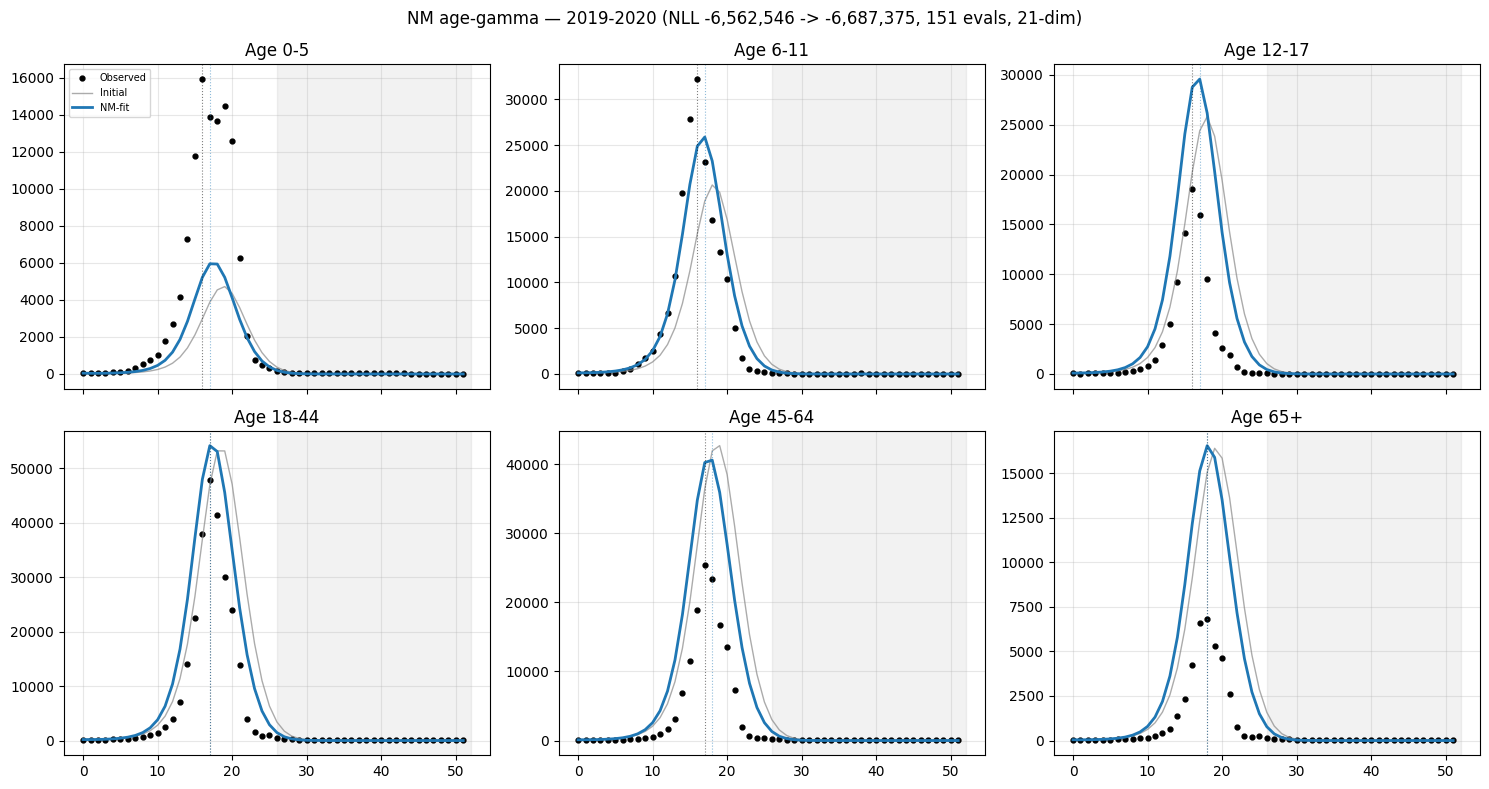

In [6]:
# Fit plot
pred_final, _ = predict_from_vec(sol.x)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, ag in zip(axes.flat, HIRA_AGE_GROUPS):
    obs = target_by_age["hira_counts"][ag]
    pi, pf = pred_init[ag], pred_final[ag]
    ax.plot(target_by_age["week_in_season"], obs, "o", color="black", ms=3.5, label="Observed")
    ax.plot(np.arange(len(pi)), pi, color="#888888", lw=1.0, alpha=0.7, label="Initial")
    ax.plot(np.arange(len(pf)), pf, color="#1f77b4", lw=2.0, label="NM-fit")
    ax.axvspan(FIRST_PEAK_END_WEEK, len(pf), alpha=0.10, color="gray")
    if obs.max() > 0: ax.axvline(int(np.argmax(obs)), color="black", ls=":", lw=0.8, alpha=0.5)
    if pf.max() > 0: ax.axvline(int(np.argmax(pf)), color="#1f77b4", ls=":", lw=0.8, alpha=0.5)
    ax.set_title(f"Age {ag}"); ax.grid(alpha=0.3)
    if ax is axes.flat[0]: ax.legend(fontsize=7)
fig.suptitle(f"NM age-gamma — {SEASON} (NLL {nll_history[0]:,.0f} -> {sol.fun:,.0f}, "
             f"{sol.nfev} evals, 21-dim)", fontsize=12)
fig.tight_layout(); fig.savefig(FIT_PNG, dpi=150, bbox_inches="tight")
print(f"saved {FIT_PNG}"); plt.show()


In [7]:
# Diagnostics
final_vec = sol.x
bounds_arr = np.array(bounds)
lo, hi = bounds_arr[:, 0], bounds_arr[:, 1]
span = hi - lo; TOL = 0.02

print("Bound hits (within 2%):")
hit_lo, hit_hi = [], []
for i, n in enumerate(names):
    if (final_vec[i] - lo[i]) / span[i] < TOL: hit_lo.append((n, final_vec[i], lo[i]))
    if (hi[i] - final_vec[i]) / span[i] < TOL: hit_hi.append((n, final_vec[i], hi[i]))
if not hit_lo and not hit_hi: print("  (none)")
for n, v, b in hit_lo: print(f"  LOWER  {n:>18}: {v:.4f}  (bound {b:.4f})")
for n, v, b in hit_hi: print(f"  UPPER  {n:>18}: {v:.4f}  (bound {b:.4f})")

print(f"\nGamma fit vs default:")
print(f"  child: {final_vec[18]:.4f} (default 0.40, range 0.30-0.50)")
print(f"  adult: {final_vec[19]:.4f} (default 0.18, range 0.12-0.25)")
print(f"  elder: {final_vec[20]:.4f} (default 0.25, range 0.18-0.35)")

# min_rate floor
n_floor = sum(int(np.sum(pred_final[ag][target_by_age["weights"][ag] > 0] < MIN_RATE))
              for ag in HIRA_AGE_GROUPS)
n_total = sum(int((target_by_age["weights"][ag] > 0).sum()) for ag in HIRA_AGE_GROUPS)
print(f"\nmin_rate floor: {n_floor}/{n_total}")

# Peak alignment + age bias
print(f"\nPeak alignment + age bias:")
peak_align = []
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]; pf = pred_final[ag]
    if obs.max() == 0 or pf.max() == 0: continue
    pw_o, pw_p = int(np.argmax(obs)), int(np.argmax(pf))
    d = pw_p - pw_o; r = pf.max() / obs.max()
    peak_align.append((ag, pw_o, pw_p, d))
    flag = "overshoot" if r > 1.5 else ("undershoot" if r < 0.66 else "ok")
    print(f"  {ag:>6}: obs W{pw_o:>2}  pred W{pw_p:>2}  delta={d:+d}  ratio={r:.2f} {flag}")

# R0 final
cal_final = vector_to_params(sol.x)
R0_final, _ = compute_R0_ngm(cal_final, dis, inputs, INITIAL_IMMUNITY)
print(f"\nR0: {R0_init:.3f} -> {R0_final:.3f}")

# Beta movement
print(f"\nBeta trajectory:")
for i, bn in enumerate(["beta_h", "beta_w", "beta_s", "beta_o"]):
    pct = (final_vec[i] - init_vec[i]) / max(abs(init_vec[i]), 1e-10) * 100
    print(f"  {bn}: {init_vec[i]:.4f} -> {final_vec[i]:.4f}  ({pct:+.1f}%)")


Bound hits (within 2%):
  LOWER              beta_h: 0.0566  (bound 0.0010)
  LOWER              beta_w: 0.0589  (bound 0.0010)
  LOWER              beta_s: 0.0631  (bound 0.0010)
  LOWER              beta_o: 0.0555  (bound 0.0010)

Gamma fit vs default:
  child: 0.3959 (default 0.40, range 0.30-0.50)
  adult: 0.1630 (default 0.18, range 0.12-0.25)
  elder: 0.2498 (default 0.25, range 0.18-0.35)

min_rate floor: 0/156

Peak alignment + age bias:
     0-5: obs W16  pred W17  delta=+1  ratio=0.37 undershoot
    6-11: obs W16  pred W17  delta=+1  ratio=0.80 ok
   12-17: obs W16  pred W17  delta=+1  ratio=1.60 overshoot
   18-44: obs W17  pred W17  delta=+0  ratio=1.13 ok
   45-64: obs W17  pred W18  delta=+1  ratio=1.60 overshoot
     65+: obs W18  pred W18  delta=+0  ratio=2.43 overshoot

R0: 1.793 -> 1.875

Beta trajectory:
  beta_h: 0.0600 -> 0.0566  (-5.6%)
  beta_w: 0.0600 -> 0.0589  (-1.9%)
  beta_s: 0.0600 -> 0.0631  (+5.2%)
  beta_o: 0.0600 -> 0.0555  (-7.4%)


saved ../outputs/calibration/sanity_nm_age_gamma_diagnostics.png


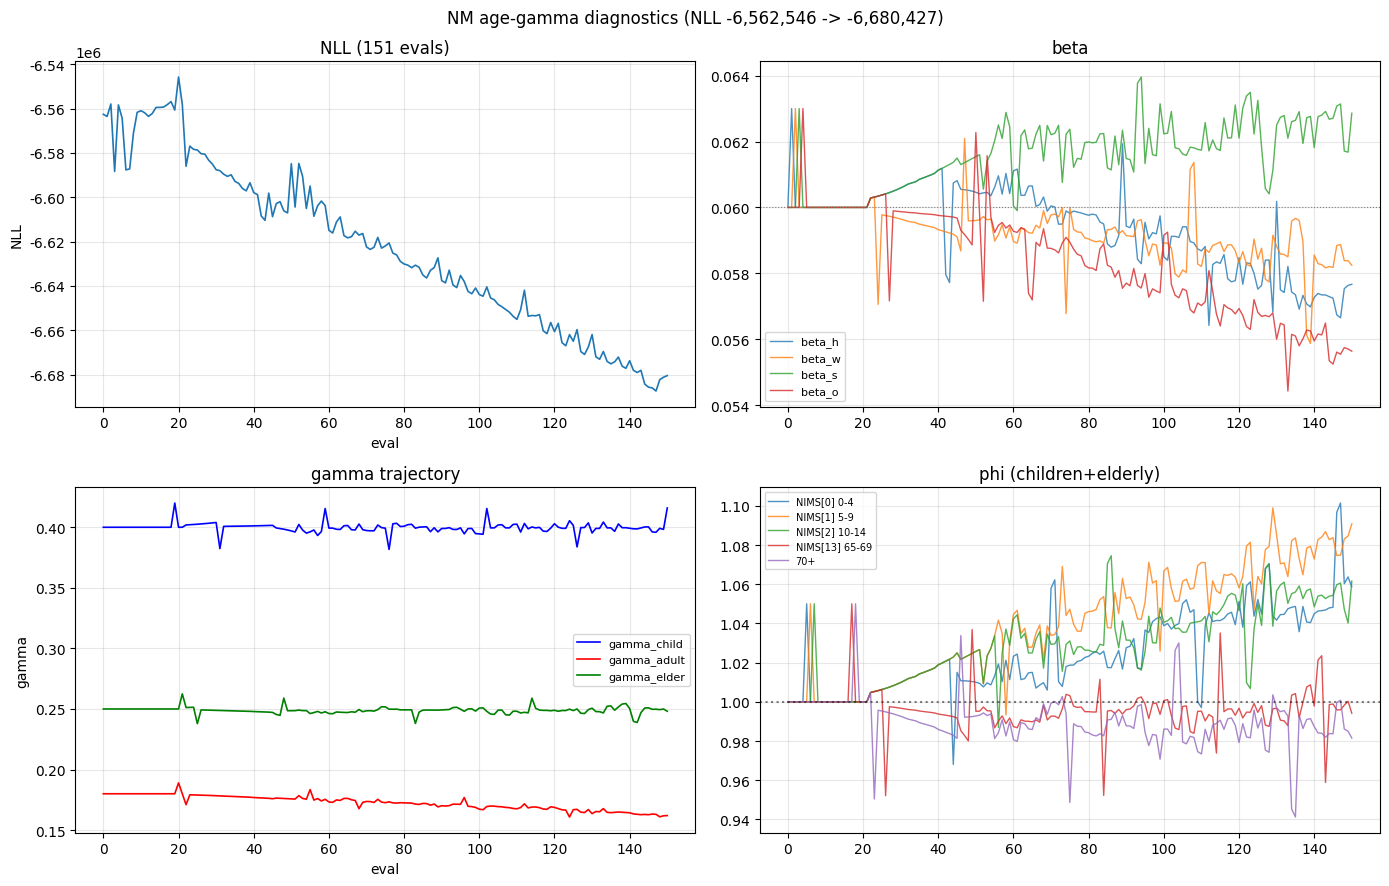

In [8]:
# Trajectory diagnostics
nll_arr = np.asarray(nll_history); vec_arr = np.asarray(vec_history)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(nll_arr, lw=1.2); ax.set_xlabel("eval"); ax.set_ylabel("NLL")
ax.set_title(f"NLL ({len(nll_arr)} evals)"); ax.grid(alpha=0.3)
if nll_arr.max() / max(nll_arr.min(), 1e-9) > 50: ax.set_yscale("log")

ax = axes[0, 1]
for i, lb in enumerate(["beta_h", "beta_w", "beta_s", "beta_o"]):
    ax.plot(vec_arr[:, i], lw=1.0, label=lb, alpha=0.8)
ax.axhline(BETA_INIT, color="gray", ls=":", lw=0.8); ax.set_title("beta")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(vec_arr[:, 18], lw=1.2, color="blue", label="gamma_child")
ax.plot(vec_arr[:, 19], lw=1.2, color="red", label="gamma_adult")
ax.plot(vec_arr[:, 20], lw=1.2, color="green", label="gamma_elder")
ax.set_title("gamma trajectory"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlabel("eval"); ax.set_ylabel("gamma")

ax = axes[1, 1]
phi_idx = {}; idx = 4
for a in range(15):
    if a == 5: continue
    phi_idx[a] = idx; idx += 1
for a in [0, 1, 2, 13, 14]:
    lb = "70+" if a == 14 else f"NIMS[{a}] {a*5}-{a*5+4}"
    ax.plot(vec_arr[:, phi_idx[a]], lw=1.0, label=lb, alpha=0.8)
ax.axhline(1.0, color="black", ls=":", alpha=0.5)
ax.set_title("phi (children+elderly)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle(f"NM age-gamma diagnostics (NLL {nll_arr[0]:,.0f} -> {nll_arr[-1]:,.0f})")
fig.tight_layout(); fig.savefig(DIAG_PNG, dpi=150, bbox_inches="tight")
print(f"saved {DIAG_PNG}"); plt.show()


In [9]:
# Save JSON
result = {
    "season": SEASON, "tag": TAG, "method": "Nelder-Mead",
    "max_iter": MAX_ITER, "n_evaluations": int(sol.nfev),
    "success": bool(sol.success), "message": str(sol.message),
    "elapsed_seconds": float(elapsed),
    "nll_initial": float(nll_history[0]), "nll_final": float(sol.fun),
    "vector_dim": len(init_vec),
    "vector_initial": [float(v) for v in init_vec],
    "vector_final": [float(v) for v in sol.x],
    "param_names": names,
    "gamma_fit": {"child": float(sol.x[18]), "adult": float(sol.x[19]), "elder": float(sol.x[20])},
    "R0_initial": float(R0_init), "R0_final": float(R0_final),
    "min_rate_floor_hits": n_floor,
    "peak_alignment": [
        {"age": ag, "obs_w": int(wo), "pred_w": int(wp), "delta": int(d)}
        for ag, wo, wp, d in peak_align
    ],
    "age_bias": {
        ag: float(pred_final[ag].max() / max(target_by_age["hira_counts"][ag].max(), 1))
        for ag in HIRA_AGE_GROUPS
    },
}
with open(JSON_PATH, "w") as f: json.dump(result, f, indent=2)
print(f"saved {JSON_PATH}")
print(f"\n=== Summary ===")
print(f"NLL: {result['nll_initial']:,.2f} -> {result['nll_final']:,.2f}")
print(f"R0: {result['R0_initial']:.3f} -> {result['R0_final']:.3f}")
print(f"Gamma: child={result['gamma_fit']['child']:.4f} "
      f"adult={result['gamma_fit']['adult']:.4f} elder={result['gamma_fit']['elder']:.4f}")
for ag in HIRA_AGE_GROUPS:
    print(f"  {ag:>6}: bias={result['age_bias'][ag]:.2f}")


saved ../outputs/calibration/sanity_nm_age_gamma.json

=== Summary ===
NLL: -6,562,546.38 -> -6,687,375.31
R0: 1.793 -> 1.875
Gamma: child=0.3959 adult=0.1630 elder=0.2498
     0-5: bias=0.37
    6-11: bias=0.80
   12-17: bias=1.60
   18-44: bias=1.13
   45-64: bias=1.60
     65+: bias=2.43
